In [1]:
!pip install tensorflow scikit-learn pandas numpy --quiet

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
import pandas as pd

df = pd.read_csv("train.csv", parse_dates=["date"])
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nSales stats:")
print(df["sales"].describe())

Shape: (913000, 4)

Columns: ['date', 'store', 'item', 'sales']

First 5 rows:
        date  store  item  sales
0 2013-01-01      1     1     13
1 2013-01-02      1     1     11
2 2013-01-03      1     1     14
3 2013-01-04      1     1     13
4 2013-01-05      1     1     10

Sales stats:
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("train.csv", parse_dates=["date"])
print("Data loaded —", df.shape)


# Store 1, Item 1 has 5 years of daily data — perfect for LSTM
store_id = 1
item_id  = 1

series = df[
    (df["store"] == store_id) &
    (df["item"]  == item_id)
].sort_values("date").reset_index(drop=True)

print(f"\nForecasting Store {store_id}, Item {item_id}")
print(f"Date range: {series['date'].min()} to {series['date'].max()}")
print(f"Total days: {len(series)}")
print(f"\nSales stats:")
print(series["sales"].describe())



series["month"]       = series["date"].dt.month
series["day_of_week"] = series["date"].dt.dayofweek
series["day_of_year"] = series["date"].dt.dayofyear


series["lag_7"]          = series["sales"].shift(7)
series["lag_14"]         = series["sales"].shift(14)
series["rolling_mean_7"] = series["sales"].rolling(7).mean()


series = series.dropna().reset_index(drop=True)
print(f"\nRows after dropping NaN: {len(series)}")


feature_cols = [
    "sales",
    "month",
    "day_of_week",
    "day_of_year",
    "lag_7",
    "lag_14",
    "rolling_mean_7"
]

#  Scale all features between 0 and 1
scaler = MinMaxScaler()
scaled = scaler.fit_transform(series[feature_cols])

print(f"\nFeature matrix shape: {scaled.shape}")


# Look at past 30 days to predict next day's sales
LOOKBACK = 30

def create_sequences(data, lookback=30):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, LOOKBACK)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"\nTraining sequences : {len(X_train)}")
print(f"Testing sequences  : {len(X_test)}")

Data loaded — (913000, 4)

Forecasting Store 1, Item 1
Date range: 2013-01-01 00:00:00 to 2017-12-31 00:00:00
Total days: 1826

Sales stats:
count    1826.000000
mean       19.971522
std         6.741022
min         4.000000
25%        15.000000
50%        19.000000
75%        24.000000
max        50.000000
Name: sales, dtype: float64

Rows after dropping NaN: 1812

Feature matrix shape: (1812, 7)

X shape: (1782, 30, 7)
y shape: (1782,)

Training sequences : 1425
Testing sequences  : 357


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, len(feature_cols))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss="mse",
    metrics=["mae"]
)

model.summary()


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True
)

# Halves learning rate if model gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


print("\nTraining LSTM model...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

print("\nTraining complete!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM model...
Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0242 - mae: 0.1202 - val_loss: 0.0199 - val_mae: 0.1108 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0160 - mae: 0.0984 - val_loss: 0.0190 - val_mae: 0.1085 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0150 - mae: 0.0957 - val_loss: 0.0146 - val_mae: 0.0968 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0151 - mae: 0.0963 - val_loss: 0.0150 - val_mae: 0.0979 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0154 - mae: 0.0963 - val_loss: 0.0147 - val_mae: 0.0972 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0147 - mae: 0.0947 - val_loss: 0.0167 - val_mae: 0.1022 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0142 - mae: 0.0936 - val_loss: 0.0150 - val_mae: 0.0974 - lear

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
RMSE (Root Mean Squared Error): 5.12 units
MAE  (Mean Absolute Error)    : 4.11 units
MAPE (Mean % Error)           : 21.21%


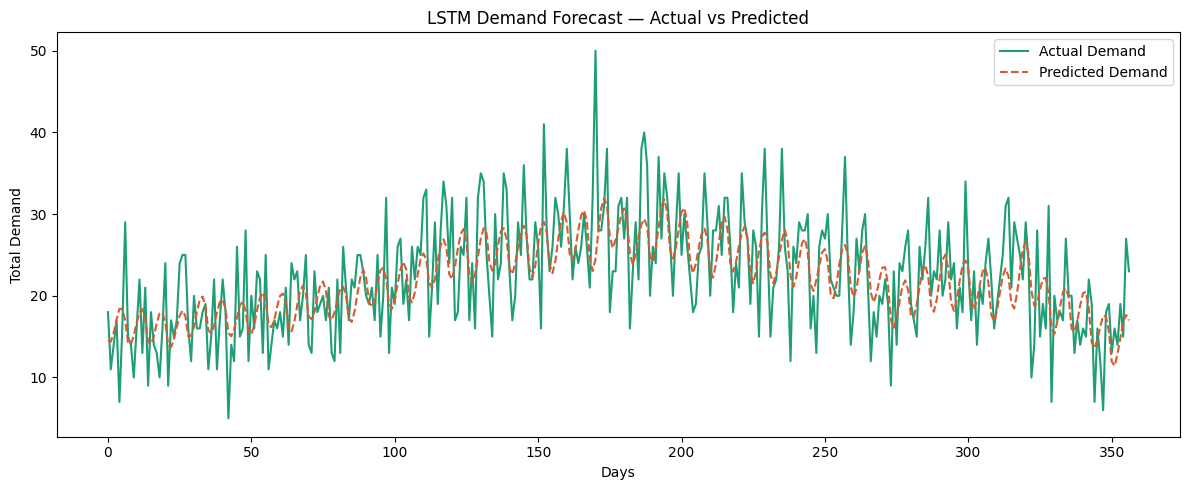

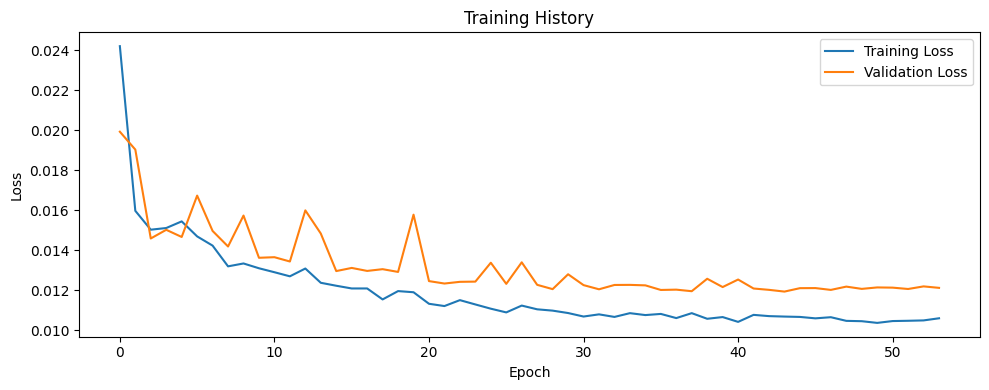

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred_scaled = model.predict(X_test)


def inverse_sales(scaled_vals, scaler, n_features):
    dummy = np.zeros((len(scaled_vals), n_features))
    dummy[:, 0] = scaled_vals.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

y_test_real = inverse_sales(y_test, scaler, len(feature_cols))
y_pred_real = inverse_sales(y_pred_scaled.flatten(), scaler, len(feature_cols))

rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
mae  = mean_absolute_error(y_test_real, y_pred_real)
mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100

print(f"RMSE (Root Mean Squared Error): {rmse:.2f} units")
print(f"MAE  (Mean Absolute Error)    : {mae:.2f} units")
print(f"MAPE (Mean % Error)           : {mape:.2f}%")

# Plot actual vs predicted demand
plt.figure(figsize=(12, 5))
plt.plot(y_test_real, label="Actual Demand", color="#1D9E75")
plt.plot(y_pred_real, label="Predicted Demand", color="#D85A30", linestyle="--")
plt.title("LSTM Demand Forecast — Actual vs Predicted")
plt.xlabel("Days")
plt.ylabel("Total Demand")
plt.legend()
plt.tight_layout()
plt.savefig("lstm_forecast_chart.png")
plt.show()

# Plot training loss curve
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("lstm_training_history.png")
plt.show()

In [7]:
import joblib

model.save("best_lstm_model.keras")
print("Model saved — best_lstm_model.keras")

# Save the scaler

joblib.dump(scaler, "lstm_scaler.pkl")
print("Scaler saved — lstm_scaler.pkl")

# Save the feature column list
import json
with open("lstm_features.json", "w") as f:
    json.dump(feature_cols, f)
print("Feature list saved — lstm_features.json")

# Save forecast chart

print("\nAll files saved!")
print("Download these 4 files:")
print("1. best_lstm_model.keras")
print("2. lstm_scaler.pkl")
print("3. lstm_features.json")
print("4. lstm_forecast_chart.png")
print("5. lstm_training_history.png")

Model saved — best_lstm_model.keras
Scaler saved — lstm_scaler.pkl
Feature list saved — lstm_features.json

All files saved!
Download these 4 files:
1. best_lstm_model.keras
2. lstm_scaler.pkl
3. lstm_features.json
4. lstm_forecast_chart.png
5. lstm_training_history.png
